# 17.3.1 稀疏性与导数噪声的失效实验

## 学习目标与先修知识

在同一轨迹（trajectory）上隔离稀疏阈值和导数（derivative）噪声的影响。

先修：17.2.1 顺序阈值最小二乘（sequential thresholded least squares，STLSQ）；随机噪声。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

移除稀疏阈值或污染导数后，训练拟合与结构恢复会同向变化吗？

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先计算一个可手算的数值，再提出本节需要核验的主张。

In [2]:
print("噪声幅度：",[0.,.2,1.]);print("预先固定种子：",1703)

噪声幅度： [0.0, 0.2, 1.0]
预先固定种子： 1703


## 模型假设

原文存在不同导数噪声设置；课程只测试 0、0.2、1.0 的加性高斯标准差（standard deviation），数字不是原文已报告的方差（variance）。每组复用训练轨迹与独立初态；所有设置事前固定，不选最佳种子。

## 数学解释与推导

无阈值最小二乘可降低训练残差（residual），却给多项式字典的许多无关项非零系数。导数噪声使 $\dot X_{obs}=\dot X+\epsilon$；固定 $\lambda$ 后比较非零项数、系数误差及独立短窗误差。噪声设定和阈值相互影响，单次结果不支持普遍优越结论。

## 核心实现

以下短函数展示方程、数值步骤和可修改的计算顺序。

In [3]:
def lorenz_rhs(state, sigma=10., rho=28., beta=8./3.):
    x,y,z=np.asarray(state,dtype=float)
    return np.array([sigma*(y-x),x*(rho-z)-y,x*y-beta*z],dtype=float)


def rk4_path(rhs, initial, h, steps):
    state=np.asarray(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        k1=np.asarray(rhs(state));k2=np.asarray(rhs(state+h*k1/2))
        k3=np.asarray(rhs(state+h*k2/2));k4=np.asarray(rhs(state+h*k3))
        state=state+h*(k1+2*k2+2*k3+k4)/6
        rows.append(state.copy())
    return np.asarray(rows)


def polynomial_library(states, degree=2):
    states=np.atleast_2d(np.asarray(states,dtype=float))
    terms=[()]
    for order in range(1,degree+1):
        terms.extend(itertools.combinations_with_replacement(range(states.shape[1]),order))
    matrix=np.column_stack([np.prod(states[:,indices],axis=1) if indices else np.ones(len(states)) for indices in terms])
    labels=['1' if not indices else '*'.join('xyz'[i] if i<3 else f'x{i}' for i in indices) for indices in terms]
    return matrix,labels


def stlsq(features, derivatives, threshold=.1, iterations=10):
    """Sequential thresholded least squares with an explicit refit per target."""
    X=np.asarray(features,dtype=float);Y=np.atleast_2d(np.asarray(derivatives,dtype=float))
    if Y.shape[0]!=X.shape[0]:Y=Y.T
    coefficients=np.linalg.lstsq(X,Y,rcond=None)[0]
    for _ in range(iterations):
        keep=np.abs(coefficients)>=threshold
        updated=np.zeros_like(coefficients)
        for column in range(Y.shape[1]):
            if keep[:,column].any():
                updated[keep[:,column],column]=np.linalg.lstsq(X[:,keep[:,column]],Y[:,column],rcond=None)[0]
        coefficients=updated
    return coefficients

## 对照实验

保持训练轨迹和字典不变，比较三档导数噪声下有无阈值筛选的非零项数与拟合残差。

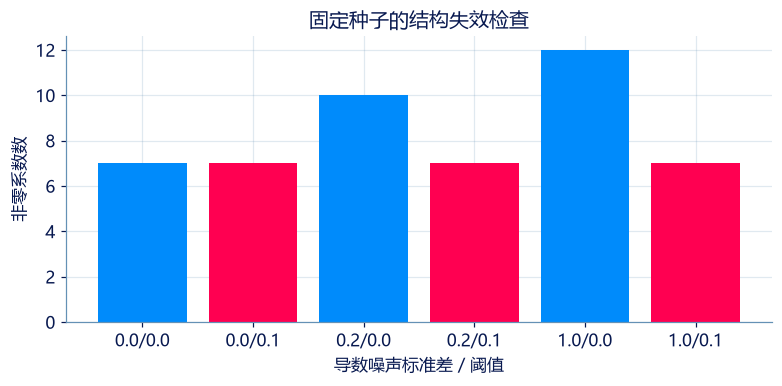

[(0.0, 0.0, 7, 4.110127130421454e-12), (0.0, 0.1, 7, 7.788276770405574e-13), (0.2, 0.0, 10, 0.3438663346279807), (0.2, 0.1, 7, 0.34667040011810374), (1.0, 0.0, 12, 1.681356557544377), (1.0, 0.1, 7, 1.6960630201476348)]


In [4]:
train=rk4_path(lorenz_rhs,[-8.,7.,27.],.01,400);Phi,labels=polynomial_library(train,2);clean=np.asarray([lorenz_rhs(s) for s in train]);rng=np.random.default_rng(1703);results=[]
for scale in [0.,.2,1.]:
    noisy=clean+scale*rng.normal(size=clean.shape)
    for threshold in [0.,.1]:
        fitted=stlsq(Phi,noisy,threshold,10);results.append((scale,threshold,int(np.count_nonzero(abs(fitted)>.05)),float(np.linalg.norm(Phi@fitted-noisy)/len(train)**.5)))
fig,ax=plt.subplots(figsize=(7,3.4));ax.bar([f"{s}/{t}" for s,t,_,_ in results],[n for _,_,n,_ in results],color=[BLUE,PINK]*3);ax.set(xlabel="导数噪声标准差 / 阈值",ylabel="非零系数数",title="固定种子的结构失效检查");ax.grid(axis="y",alpha=.2);plt.show();print(results)

## 结果解释

在这条 Lorenz 训练轨迹上，无阈值拟合保留更多项；加入三档噪声后，系数与稀疏模式也随之变化。把保留项与已知系数对照，可以区分拟合残差变小和方程项恢复。后面的配对统计练习使用题目给定的结果表。

### 独立核对

比较同档噪声下的保留项数，再用无噪声结果核对已知系数。

In [5]:
assert results[0][2]>=results[1][2];assert results[2][2]>=results[3][2]
np.testing.assert_allclose(stlsq(Phi,clean,.1,10)[[labels.index("x"),labels.index("y")],0],[-10,10],atol=.1)
print("稀疏项数与无噪声真实系数核验通过。")

稀疏项数与无噪声真实系数核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/explore/)。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：消融隔离

怎样单独考察稀疏性？

- **A.** 同时改变字典与噪声
- **B.** 固定同一轨迹（trajectory）和导数（derivative），只改变阈值
- **C.** 挑最好种子
- **D.** 更换测试初态与指标

[作答：消融隔离](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/practice/?question=p17-c3s1-choice1)

### 第 2 题 · 单项选择题：导数污染

导数（derivative）上添加噪声后的拟合，能推出什么？

- **A.** 所有真实测量均一样困难
- **B.** 只支持声明噪声与样本条件下的结果
- **C.** 训练残差（residual）越低结构一定越真
- **D.** 混沌（chaos）使短时测试无意义

[作答：导数污染](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/practice/?question=p17-c3s1-choice2)

### 第 3 题 · Python 计算题：带噪导数重拟合

移除稀疏阈值或污染导数（derivative）后，训练拟合与结构恢复会同向变化吗？本题计算“带噪导数重拟合”：先最小二乘，再迭代将 |系数|<threshold 的位置清零；各状态（state）列只在保留列上重拟合。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    features: list[list[float]],
    derivatives: list[list[float]],
    threshold: float,
    iterations: int,
) -> list[list[float]]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `features` | `list[list[float]]` | 样本×候选项设计矩阵（design matrix）。 | 混合 |
| `derivatives` | `list[list[float]]` | 样本×状态导数矩阵（matrix）。 | 状态/T |
| `threshold` | `float` | 原系数量纲（dimension）下的绝对值阈值。 | 系数 |
| `iterations` | `int` | 顺序筛除并重拟合次数。 | 轮 |

**返回值**

直接返回 coefficients（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `coefficients` | `list[list[float]]` | 候选项×状态的系数矩阵。 | 混合 |

**计算规则**

先最小二乘，再迭代将 |系数|<threshold 的位置清零；各状态列只在保留列上重拟合。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| features | 样本×候选项设计矩阵（design matrix）。 | [[1.0, 0.0], [1.0, 1.0], [1.0, 2.0]] | 混合 |
| derivatives | 样本×状态导数矩阵（matrix）。 | [[1.0], [3.0], [5.0]] | 状态/T |
| threshold | 原系数量纲（dimension）下的绝对值阈值。 | 0.1 | 系数 |
| iterations | 顺序筛除并重拟合次数。 | 2 | 轮 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
features = [[1.0, 0.0], [1.0, 1.0], [1.0, 2.0]]
derivatives = [[1.0], [3.0], [5.0]]
threshold = 0.1
iterations = 2

result = solve(features, derivatives, threshold, iterations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| coefficients | 候选项×状态的系数矩阵。 | [[0.9999999999999997], [1.9999999999999998]] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.9999999999999997],
                   [1.9999999999999998]]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；先最小二乘，再迭代将 |系数|<threshold 的位置清零；各状态列只在保留列上重拟合。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：带噪导数重拟合](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/practice/?question=p17-noisy-refit)

### 第 4 题 · Python 计算题：候选支持项

移除稀疏阈值或污染导数（derivative）后，训练拟合与结构恢复会同向变化吗？本题计算“候选支持项”：返回 [1,x,y,z,x²,xy,xz,y²,yz,z²]。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    state: list[float],
) -> list[float]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 三个状态（state） x、y、z。 | 模型状态 |

**返回值**

直接返回 terms（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `terms` | `list[float]` | 常数、一次和二次项的固定顺序。 | 混合 |

**计算规则**

返回 [1,x,y,z,x²,xy,xz,y²,yz,z²]。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 三个状态（state） x、y、z。 | [2.0, 3.0, 4.0] | 模型状态 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [2.0, 3.0, 4.0]

result = solve(state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| terms | 常数、一次和二次项的固定顺序。 | [1.0, 2.0, 3.0, 4.0, 4.0, 6.0, 8.0, 9.0, 12.0, 16.0] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0,
                   2.0,
                   3.0,
                   4.0,
                   4.0,
                   6.0,
                   8.0,
                   9.0,
                   12.0,
                   16.0]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；返回 [1,x,y,z,x²,xy,xz,y²,yz,z²]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：候选支持项](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/practice/?question=p17-support-row)

**原始参考**

[Brunton、Proctor 与 Kutz，arXiv:1509.03580v1](https://arxiv.org/abs/1509.03580v1)